Load data: filtered_data\240710\two_timesteps_240710_240808.ohm
Load data: filtered_data\240808\two_timesteps_240710_240808.ohm


14/11/25 - 16:05:33 - pyGIMLi - INFO - Found 2 regions.
14/11/25 - 16:05:33 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
14/11/25 - 16:05:33 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/11/25 - 16:05:33 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/11/25 - 16:05:33 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
14/11/25 - 16:05:33 - pyGIMLi - INFO - Use median(data values)=2117.76
14/11/25 - 16:05:33 - pyGIMLi - INFO - Created startmodel from forward operator: 3104, min/max=2117.760000/2117.760000
14/11/25 - 16:05:33 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000020291D68950>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000020290EDFE20>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000020291CEC6D0>
min/max (data): 77.42/6811
min/max (error): 4.3%/4.31%
min/max (start model): 2118/2118
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  500.83
--------------------------------------------------------------------------------
inv.iter 1 ... 

14/11/25 - 16:05:54 - pyGIMLi - INFO - Found 2 regions.
14/11/25 - 16:05:54 - pyGIMLi - INFO - Region with smallest marker (1) set to background
14/11/25 - 16:05:54 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/11/25 - 16:05:54 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


chi² =    9.58 (dPhi = 96.97%) lam: 20.0


...

3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736
fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x0000020290F22430>
Data transformation: <pgcore._pygimli_.RTrans object at 0x00000202925A2500>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000020291F45C10>
min/max (data): 75.9/6811
min/max (error): 3.14%/4.31%
min/max (start model): 2030/2030
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 10086.53
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  250.37 (dPhi = 97.48%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   73.75 (dPhi = 70.31%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.79 (dPhi = 95.04%) lam: 12.0
--------------------------------------------------------------------------------
i

14/11/25 - 16:08:27 - pyGIMLi - INFO - Found 2 regions.
14/11/25 - 16:08:27 - pyGIMLi - INFO - Region with smallest marker (1) set to background
14/11/25 - 16:08:27 - pyGIMLi - INFO - Creating forward mesh from region infos.
14/11/25 - 16:08:27 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
14/11/25 - 16:08:27 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


14/11/25 - 16:08:28 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000202918DD9E0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000002029414D620>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x00000202947CB600>
min/max (data): 46.5/5544
min/max (error): 3.14%/4.31%
min/max (start model): 1548/1548
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 13628.75
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  371.89 (dPhi = 97.24%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  126.51 (dPhi = 65.85%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.75 (dPhi = 96.17%) lam: 12.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    2.08 (dPhi = 16.42%) lam: 12.0
-----------

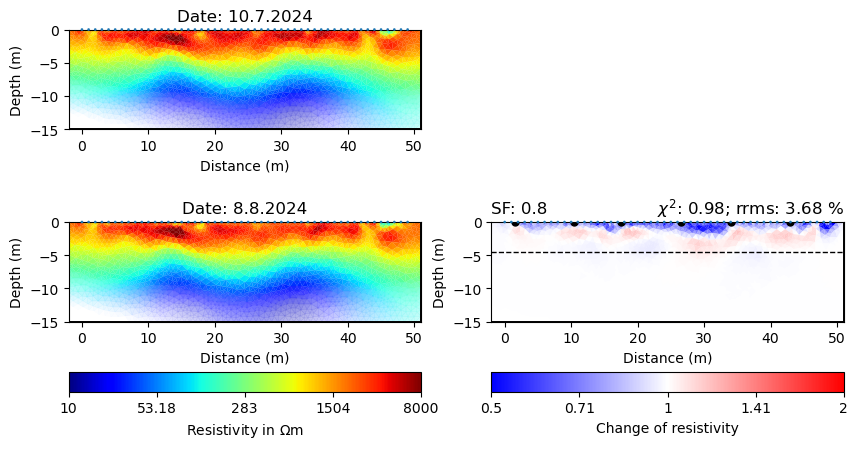

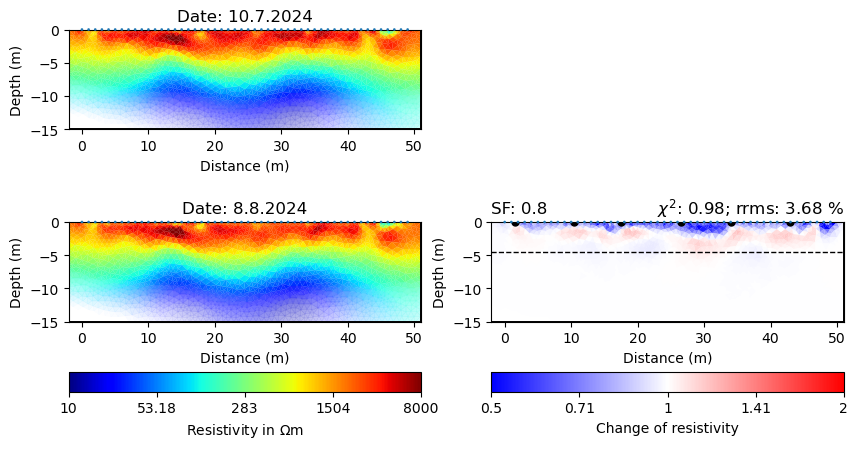

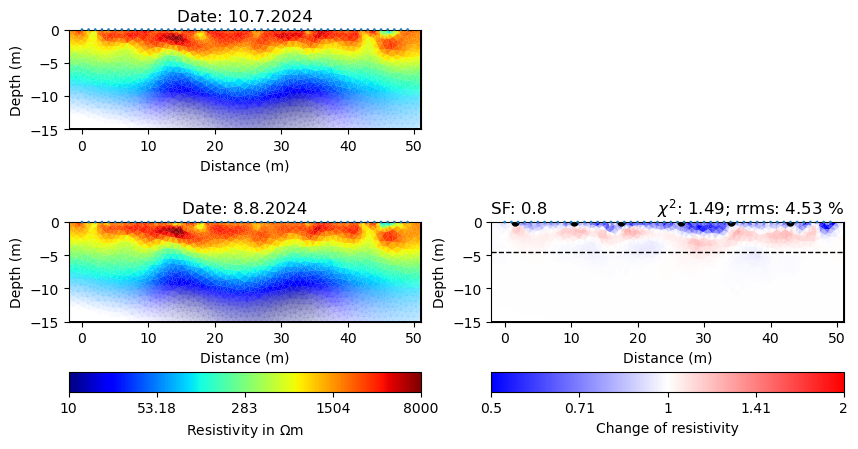

In [5]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps_240710_240808.ohm"
two_timesteps = False
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps_240710_240808.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)

# Inversion without temperature correction
DATA = [dat[1] for dat in data]
# Full time-lapse
scalef = 0.8
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
fop.setMesh(mesh)
print(fop.mesh()) 
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 12, startModel=startModel, verbose=True)
chi2 = []
rrms = []
chi2.append(round(inv.chi2(),2))
rrms.append(round(inv.relrms(),2))
mod = np.reshape(model, [len(DATA), -1])

# PLot
plotting_function_FTL(data,manager = manager, results = mod, folder_name= 'Fig16', filename= 'two_timesteps_240710_240808_without_Tcorr_new', chi2=chi2, scalef=scalef, rrms=rrms)
plotting_function_FTL(data,manager = manager, results = mod, folder_name= 'Fig16', filename= 'two_timesteps_240710_240808_without_Tcorr_new', chi2=chi2, scalef=scalef, rrms=rrms)

# Temperature correction    
ort_2 = 'Georg-Westermann-Park'
mod_corr = []
temp_spread = []
timestep = 0
mesh2 = manager[0].mesh.createSubMesh(manager[0].mesh.cells(manager[0].mesh.cellMarkers() == 2))
for count, m in enumerate(mod):
    timestep = count+10 #(for 240710-240808) or count+1 (for 230809-231108)
    dateien = os.listdir(r".\Temperature_data/" + ort_2 )
    for datei in dateien: 
        if (datei).startswith('T_Profil%s_array' % (str(timestep))):
            print(datei)
            Temp_tiefe_vektor = np.load(r'.\Temperature_data/%s/' % (ort_2) + datei, allow_pickle=True)
    res_new,Tem_new = T_corr_nach_Inversion(m, mesh2, Temp_tiefe_vektor)
    mod_corr.append(res_new)
    temp_spread.append(Tem_new)

modell2 = np.reshape(mod, -1)
modell_corr = np.reshape(mod_corr, -1)
response = inv.fop.response(modell2)
response_t_corr = inv.fop.response(modell_corr)
difference = response_t_corr - response
diff = np.reshape(difference, [len(DATA), -1])
for h in range(len(diff)):
    DATA[h]['rhoa'] = DATA[h]['rhoa'] + diff[h]
    
    
# Inversion with temperature correction
# Full time-lapse
scalef = 0.8
fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
fop.setData(DATA)
#manager[0].createMesh(quality=34,paraMaxCellSize=20)
fop.setMesh(mesh)
print(fop.mesh())  # important to call mesh() function once!
dataVec = np.concatenate([data["rhoa"] for data in DATA])
errorVec = np.concatenate([data["err"] for data in DATA])
startModel = fop.createStartModel(dataVec)
inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
model = inv.run(dataVec, errorVec, maxIter=10, lam= 12, startModel=startModel, verbose=True)
chi2 = []
rrms = []
chi2.append(round(inv.chi2(),2))
rrms.append(round(inv.relrms(),2))
kw = dict(cMin=10, cMax=300, logScale=True, cMap="jet")
pd = fop.paraDomain
mod_Tcorr = np.reshape(model, [len(DATA), -1])

# Plot 
plotting_function_FTL(data, manager = manager,results = mod_Tcorr, folder_name= 'Fig16', filename= 'two_timesteps_240710_240808_with_Tcorr_new', chi2=chi2, scalef=scalef, rrms = rrms)